# INFO 5613 – Class 21: Similarity and homophily

[Brian C. Keegan, Ph.D.](http://brianckeegan.com/)  
[Assistant Professor, Department of Information Science](https://www.colorado.edu/cmci/people/information-science/brian-c-keegan)  
University of Colorado Boulder  

Copyright and distributed under an [MIT License](https://opensource.org/licenses/MIT)

## Import libraries

In [2]:
# Load networkx for working with network data
import networkx as nx

# Load numpy for working with numerical data
import numpy as np

# Load pandas for working with tabular data
import pandas as pd

# Load visualization libraries
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import seaborn as sb

# Load libraries
import scipy.stats as stats

# Define a formatting string we can use to print the number of nodes and edges
node_edge_s = "There are {0:,} nodes and {1:,} edges in the network. Density is {2:.3f}"

## Load one network

In [16]:
snap0_g = nx.read_gexf('107.gexf')

_lcc = nx.subgraph(snap0_g,sorted(nx.components.connected_components(snap0_g),key=len,reverse=True)[0])

pos = nx.layout.kamada_kawai_layout(_lcc)

In [5]:
snap0_g.nodes(data=True)['236'].keys()

dict_keys(['gender', 'degree', 'locale', 'label'])

## Visualize attributes on a network

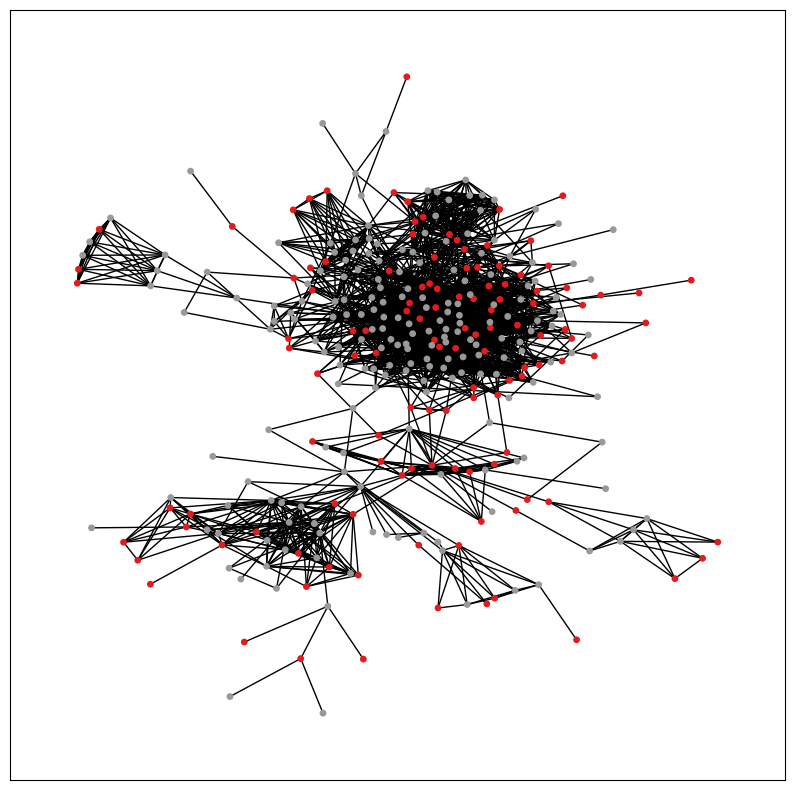

In [6]:
f,ax = plt.subplots(figsize=(10,10))
nx.draw_networkx(_lcc,
                 pos=pos,
                 node_size=15,
                 with_labels=False,
                 node_color=[d['gender'] for n,d in dict(_lcc.nodes(data=True)).items()],
                 ax=ax,
                 cmap='Set1'
                )

In [7]:
nx.assortativity.attribute_assortativity_coefficient(snap0_g,'gender')

0.08220341180241966

<AxesSubplot:>

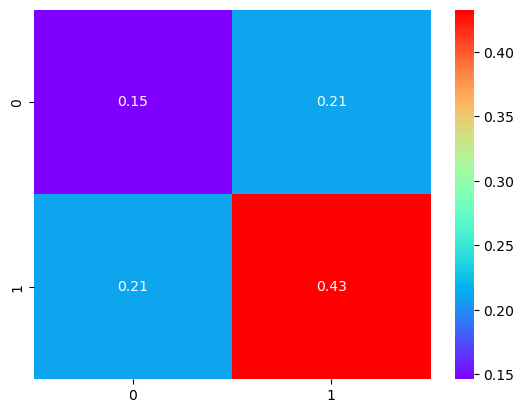

In [8]:
sb.heatmap(nx.assortativity.attribute_mixing_matrix(snap0_g,'gender'),
#            norm=mcolors.SymLogNorm(linthresh=1e-3),
           annot=True,
           cmap='rainbow'
          )

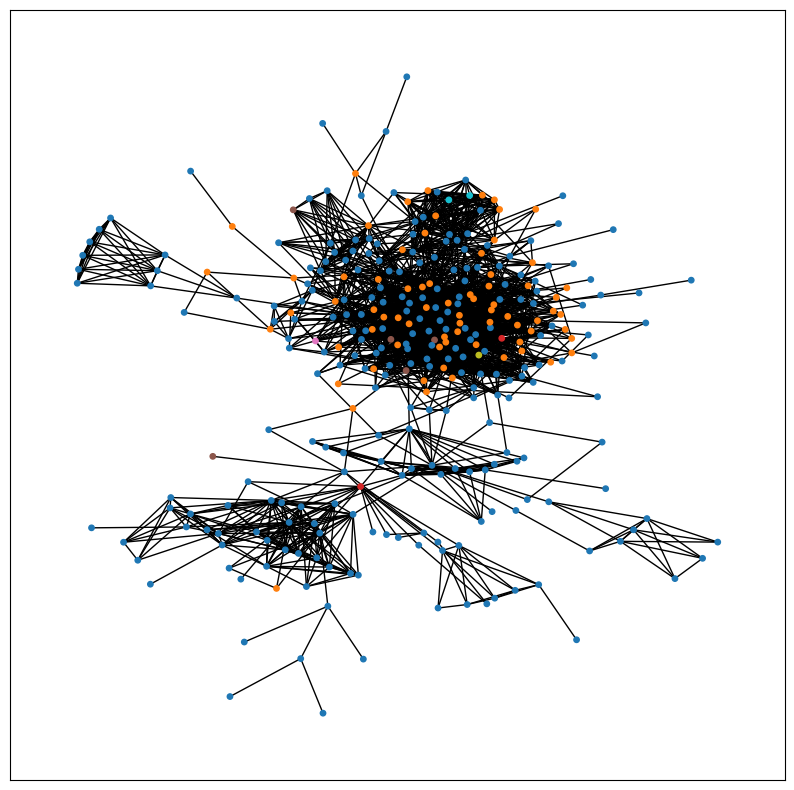

In [9]:
f,ax = plt.subplots(figsize=(10,10))
nx.draw_networkx(_lcc,
                 pos=pos,
                 node_size=15,
                 with_labels=False,
                 node_color=[d['degree'] for n,d in dict(_lcc.nodes(data=True)).items()],
                 ax=ax,
                 cmap='tab10'
                )

In [10]:
nx.assortativity.attribute_assortativity_coefficient(snap0_g,'degree')

0.06833302512009566

<AxesSubplot:>

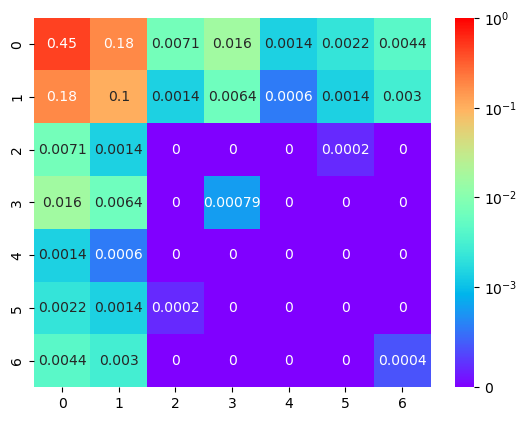

In [11]:
sb.heatmap(nx.assortativity.attribute_mixing_matrix(snap0_g,'degree'),
           norm=mcolors.SymLogNorm(vmax=1e0,linthresh=1e-3),
           annot=True,
           cmap='rainbow'
          )

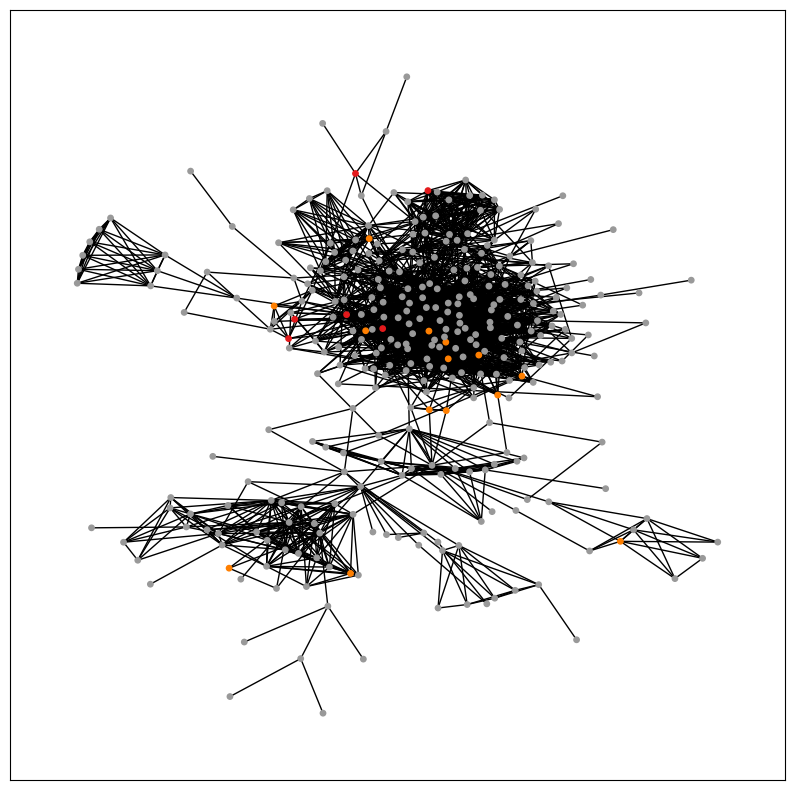

In [12]:
f,ax = plt.subplots(figsize=(10,10))
nx.draw_networkx(_lcc,
                 pos=pos,
                 node_size=15,
                 with_labels=False,
                 node_color=[d['locale'] for n,d in dict(_lcc.nodes(data=True)).items()],
                 ax=ax,
                 cmap='Set1'
                )

In [13]:
nx.assortativity.attribute_assortativity_coefficient(snap0_g,'locale')

-0.012017871728091802

<AxesSubplot:>

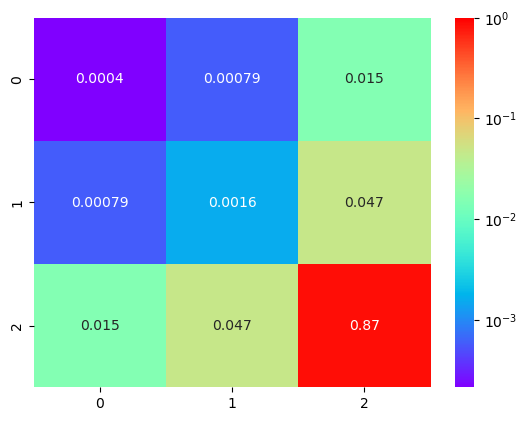

In [14]:
sb.heatmap(nx.assortativity.attribute_mixing_matrix(snap0_g,'locale'),
           norm=mcolors.SymLogNorm(vmax=1e0,linthresh=1e-3),
           annot=True,
           cmap='rainbow'
          )

## Appendix

Facebook networks from SNAP: [Facebook social circles](https://snap.stanford.edu/data/ego-Facebook.html)

In [156]:
def make_attribute_graph(file_num):
    _g = nx.read_edgelist('facebook/{0}.edges'.format(file_num),create_using=nx.Graph)
    
    # Load feature names
    _featnames = pd.read_csv('facebook/{0}.featnames'.format(file_num),header=None,sep=' ',index_col=0)

    # Load features
    _feat_df = pd.read_csv('facebook/{0}.feat'.format(file_num),header=None,sep=' ',index_col=0)

    # Assign feature names to columns
    _feat_df.columns = _featnames[1]

    # https://stackoverflow.com/a/43792894/1574687
    _feat_df.columns = pd.io.parsers.base_parser.ParserBase({'names':_feat_df.columns, 'usecols':None})._maybe_dedup_names(_feat_df.columns)

    # Add 0s in
    cols = []
    for c in _feat_df.columns:
        if c[-1] == 'd':
            c += '.0'
            cols.append(c)
        else:
            cols.append(c)

    _feat_df.columns = cols

    # Add gender
    for k,v in dict_maker(_feat_df,'gender;anonymized').items():
        try:
            _g.nodes[str(k)]['gender'] = v
        except:
            pass

    # Add degrees
    for k,v in dict_maker(_feat_df,'education;concentration').items():
        try:
            _g.nodes[str(k)]['degree'] = v
        except:
            pass

    # Add locale
    for k,v in dict_maker(_feat_df,'locale').items():
        try:
            _g.nodes[str(k)]['locale'] = v
        except:
            pass
        
    return _g

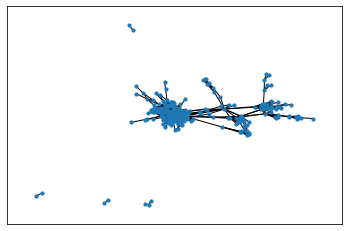

In [154]:
nx.draw_networkx(make_attribute_graph(0),
                 node_size=10,
                 with_labels=False)

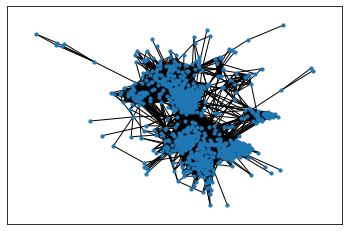

In [157]:
nx.draw_networkx(make_attribute_graph(107),
                 node_size=10,
                 with_labels=False)

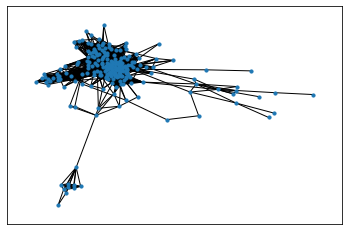

In [158]:
nx.draw_networkx(make_attribute_graph(348),
                 node_size=10,
                 with_labels=False)

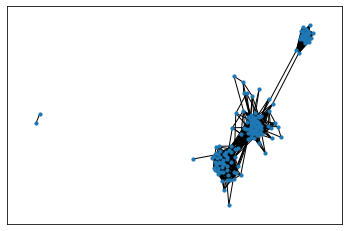

In [159]:
nx.draw_networkx(make_attribute_graph(414),
                 node_size=10,
                 with_labels=False)

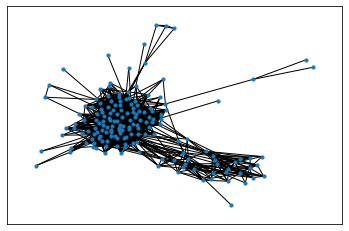

In [160]:
nx.draw_networkx(make_attribute_graph(686),
                 node_size=10,
                 with_labels=False)

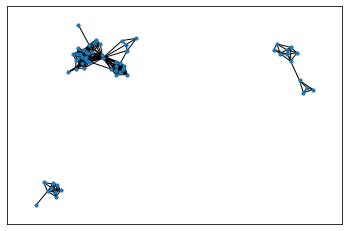

In [161]:
nx.draw_networkx(make_attribute_graph(698),
                 node_size=10,
                 with_labels=False)

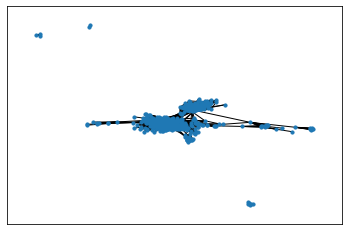

In [162]:
nx.draw_networkx(make_attribute_graph(1684),
                 node_size=10,
                 with_labels=False)

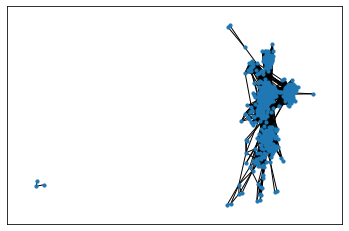

In [163]:
nx.draw_networkx(make_attribute_graph(1912),
                 node_size=10,
                 with_labels=False)

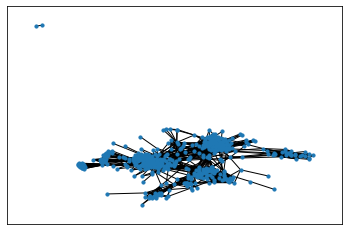

In [164]:
nx.draw_networkx(make_attribute_graph(3437),
                 node_size=10,
                 with_labels=False)

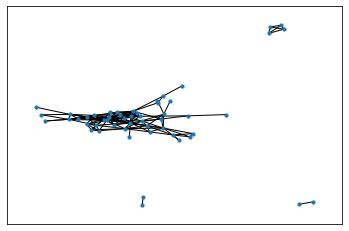

In [165]:
nx.draw_networkx(make_attribute_graph(3980),
                 node_size=10,
                 with_labels=False)

In [166]:
for network in [0,107,348,414,686,698,1684,1912,3437,3980]:
    _g = make_attribute_graph(network)
    nx.write_gexf(_g,"{0}.gexf".format(network))